In [1]:
"""
FE_OT_matching.py

Compare the finite-energy (FE) 4D Monte-Carlo integrator with the optical
theorem (OT) radial+z integration in the small-xB limit at fixed Q.

This script:
 - computes FE longitudinal and transverse cross sections via
   compute_cross_section_4D (VEGAS wrapper)
 - computes OT longitudinal and transverse cross sections via a
   deterministic dblquad over (r,z) using the LO optical-theorem
   photon wavefunctions and the Dipole.S(r) amplitude
 - converts both to structure functions F_L, F_T using the same
   prefactor and prints them for comparison as xB -> small.

This file intentionally avoids relying on other helper wrappers which
had inconsistent interfaces in this repository; instead it uses the
wavefunction methods directly (psi_T_squared / psi_L_squared) and the
Dipole.S(r) method.
"""

import os
import sys
import numpy as np
from scipy.integrate import dblquad
import multiprocessing

# Try to import the VEGAS-based FE integrator. If the module isn't on
# sys.path (running tests from repo root), add the local numerics LO path
try:
    from Integration_functions_4D import compute_cross_section_4D
except ModuleNotFoundError:
    # In a Jupyter notebook __file__ is not defined; use the current working
    # directory as a fallback to locate the repo root and numerics path.
    repo_root = os.path.normpath(os.path.join(os.getcwd(), "..", ".."))
    numerics_lo = os.path.join(repo_root, "Physics_code_library", "physicslib", "numerics", "totalDIS", "LO")
    if os.path.isdir(numerics_lo):
        sys.path.insert(0, numerics_lo)
        from Integration_functions_4D import compute_cross_section_4D
    else:
        # As a last resort try inserting the current working directory and
        # attempt the import again so this cell is more robust in notebook runs.
        sys.path.insert(0, os.getcwd())
        from Integration_functions_4D import compute_cross_section_4D

from physicslib.wavefunctions.OT_photon_wavefunctions.LO import LO_OT_PhotonWF_squared
from physicslib.multipole_models.MV_models.dipole import Dipole


In [2]:
# Fixed kinematics
Q = 5.0  # GeV
m = 0.14
Zf = np.sqrt(2.0 / 3.0)
sigma0 = 2.57 * 2 * 18.81

# Integration settings
r_max = 40.0
zmin, zmax = 1e-6, 1.0 - 1e-6
mcpoints = int(1e6)  # for FE VEGAS runs (can reduce for quick checks)
n_cores = multiprocessing.cpu_count()

# FE inputs that will be passed to compute_cross_section_4D
umin, umax = 1e-6, r_max
upmin, upmax = 1e-6, r_max
thetamin, thetamax = 0.0, 2.0 * np.pi

# xB grid to test the small-xB approach
xB_values = np.linspace(1e-6, 1e-2, 15)
Qsq_values = [Q**2 * (1.0 / xB - 1.0) for xB in xB_values]

# Instantiate OT photon wavefunction and Dipole model
quark_masses = np.array([m])
quark_charges = np.array([Zf])
ot_wf = LO_OT_PhotonWF_squared(quark_masses, quark_charges)
dipole_model = Dipole(Qs0=np.sqrt(0.104), gamma=1.0, ec=1.0)

In [3]:
# Helper: deterministic OT integrand (r,z) for a chosen polarization
def OT_radial_z_integrand(r, z, Q, polarization, flavor=0):
    # wavefunction squared
    if polarization == "T":
        wf_sq = ot_wf.psi_T_squared(Q, r, z, flavor)
    else:
        wf_sq = ot_wf.psi_L_squared(Q, r, z, flavor)

    DipoleAmp = 2.0 * (1.0 - dipole_model.S(r))
    Jac = 2.0 * np.pi * r / (z * (1.0 - z))

    return (sigma0 / 2.0) * (1.0 / (4.0 * np.pi)) * Jac * wf_sq * DipoleAmp

# Prefactor to convert cross-sections to structure functions
alphaEM = 1.0 / 137.0
prefactor = Q**2 / ((4.0 * np.pi**2) * alphaEM)

# Collect FE results across xB so we can plot them versus Q^2(1/xB - 1)
FL_FE_list = []
FT_FE_list = []

for xB in xB_values:
    # FE (VEGAS) integrator (fast check: use fewer points if desired)
    sigmaL, sigmaL_err = compute_cross_section_4D(
        Q=Q,
        xB=xB,
        m=m,
        Zf=Zf,
        polarization="L",
        largeNc=False,
        umin=umin,
        umax=umax,
        upmin=upmin,
        upmax=upmax,
        zmin=zmin,
        zmax=zmax,
        thetamin=thetamin,
        thetamax=thetamax,
        mcpoints=mcpoints,
        n_cores=n_cores,
        z_target_override=None,
    )

    sigmaT, sigmaT_err = compute_cross_section_4D(
        Q=Q,
        xB=xB,
        m=m,
        Zf=Zf,
        polarization="T",
        largeNc=False,
        umin=umin,
        umax=umax,
        upmin=upmin,
        upmax=upmax,
        zmin=zmin,
        zmax=zmax,
        thetamin=thetamin,
        thetamax=thetamax,
        mcpoints=mcpoints,
        n_cores=n_cores,
        z_target_override=None,
    )

    FL_FE = prefactor * sigmaL
    FT_FE = prefactor * sigmaT

    FL_FE_list.append(FL_FE)
    FT_FE_list.append(FT_FE)

# Optical theorem deterministic integrals (dblquad: z varies faster than r)
# dblquad expects func(z, r) when integrating r outer, z inner via
# dblquad(lambda z, r: f(r,z), rmin, rmax, zmin_func, zmax_func)
OT_L_val, OT_L_err = dblquad(
    lambda z, r: OT_radial_z_integrand(r, z, Q, "L"),
    0.0, r_max,
    lambda r: zmin, lambda r: zmax,
    epsabs=1e-6, epsrel=1e-4,
)

OT_T_val, OT_T_err = dblquad(
    lambda z, r: OT_radial_z_integrand(r, z, Q, "T"),
    0.0, r_max,
    lambda r: zmin, lambda r: zmax,
    epsabs=1e-6, epsrel=1e-4,
)

FL_OT = prefactor * OT_L_val
FT_OT = prefactor * OT_T_val


/home/ermabert/.local/lib/python3.9/site-packages/scipy/integrate/_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


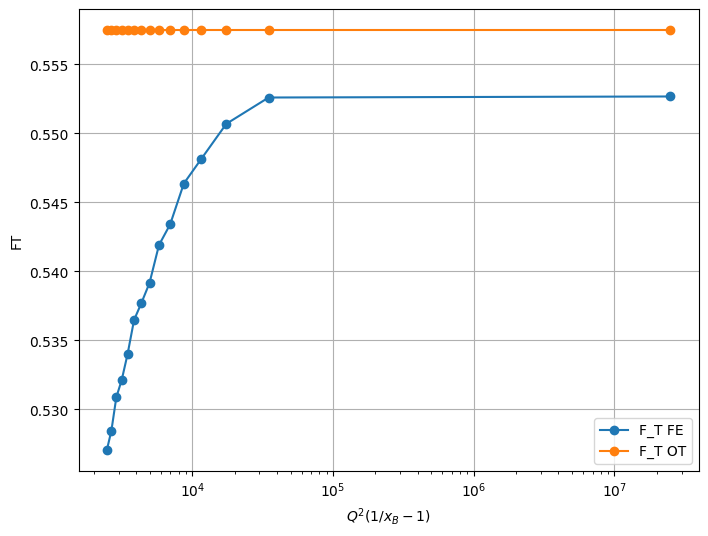

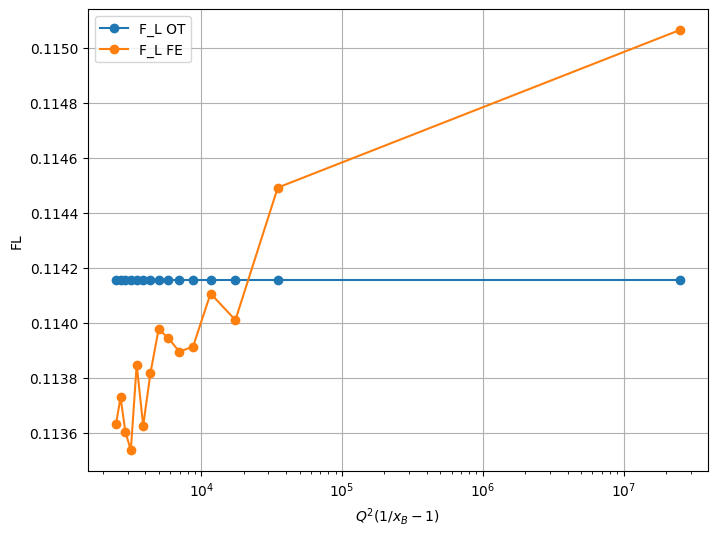

In [4]:
# Plot the results as a function of Q^2(1/xB -1) 
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(Qsq_values, FT_FE_list, "o-", label="F_T FE")
plt.plot(Qsq_values, [FT_OT] * len(Qsq_values), "o-", label="F_T OT")
plt.xscale("log")
plt.xlabel(r"$Q^2(1/x_B - 1)$")
plt.ylabel("FT")
plt.legend()
plt.grid()

plt.figure(figsize=(8, 6))
plt.plot(Qsq_values, [FL_OT] * len(Qsq_values), "o-", label="F_L OT")
plt.plot(Qsq_values, FL_FE_list, "o-", label="F_L FE")
plt.xscale("log")
plt.xlabel(r"$Q^2(1/x_B - 1)$")
plt.ylabel("FL")
plt.legend()
plt.grid()
plt.show()

